# TT-20 - SVR: Du doan cuong do chiu nen be tong


In [2]:
!pip install xlrd

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Concrete_Data.xls")
df.columns = ["cement", "slag", "fly_ash", "water", "superplasticizer",
              "coarse_agg", "fine_agg", "age", "strength"]
print(df.shape)
df.describe()


(1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## 1. EDA: scatter tung dac trung vs cuong do, heatmap tuong quan

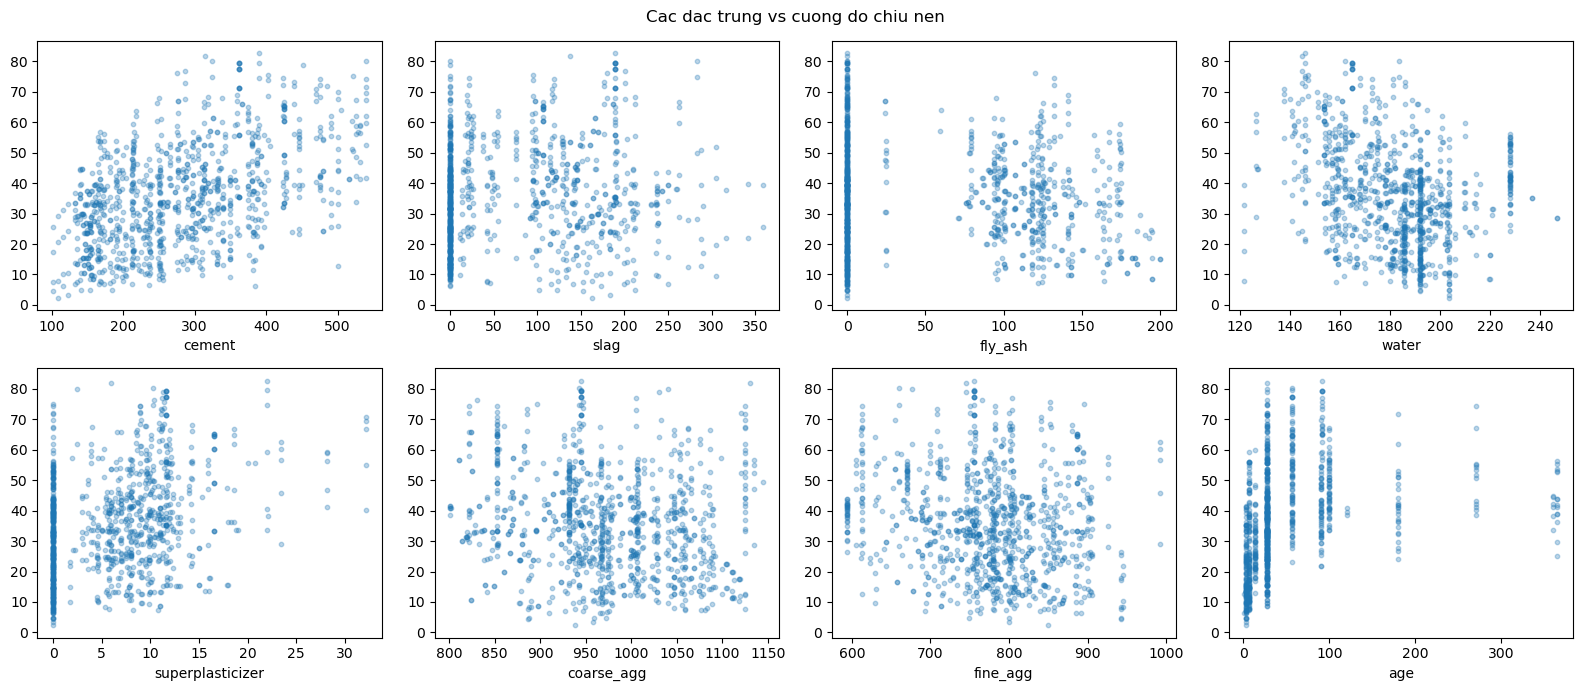

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), df.columns[:-1]):
    ax.scatter(df[col], df["strength"], alpha=0.3, s=10)
    ax.set_xlabel(col)
plt.suptitle("Cac dac trung vs cuong do chiu nen")
plt.tight_layout()
plt.show()


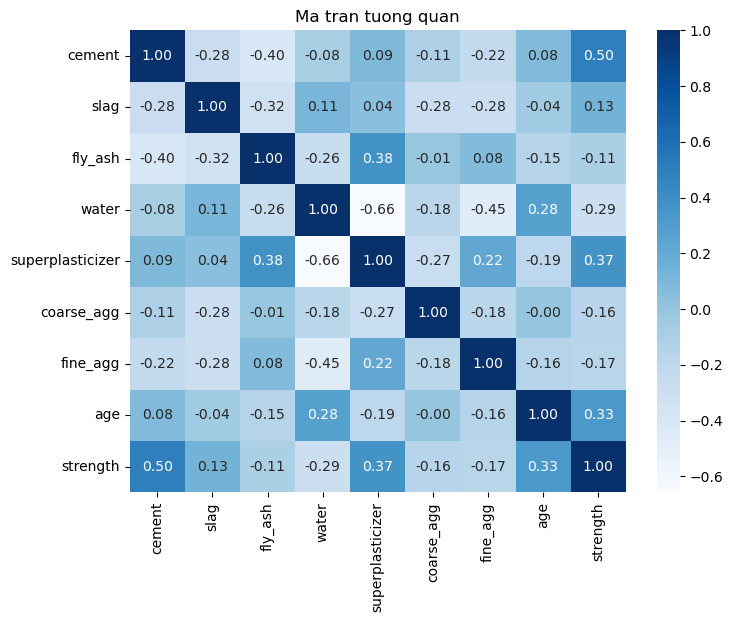

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Ma tran tuong quan")
plt.show()


## 2. Tao dac trung tu kien thuc mien

In [6]:
# water_cement_ratio la yeu to quyet dinh trong nganh xay dung, model khong tu nghi ra duoc
df["water_cement_ratio"] = df["water"] / df["cement"]
df["tong_chat_ket_dinh"] = df["cement"] + df["slag"] + df["fly_ash"]
df["log_age"] = np.log1p(df["age"])   # Age lech phai manh, quan he voi cuong do gan voi log(Age)

print(df[["water_cement_ratio", "tong_chat_ket_dinh", "log_age"]].describe())


       water_cement_ratio  tong_chat_ket_dinh      log_age
count         1030.000000         1030.000000  1030.000000
mean             0.748269          409.248252     3.242209
std              0.314005           92.783290     1.110431
min              0.266893          200.000000     0.693147
25%              0.533333          336.380000     2.079442
50%              0.675349          391.350000     3.367296
75%              0.935014          483.700000     4.043051
max              1.882353          640.000000     5.902633


## 3. Baseline: DummyRegressor + Linear Regression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

feature_cols = ["cement", "slag", "fly_ash", "water", "superplasticizer",
                 "coarse_agg", "fine_agg", "age",
                 "water_cement_ratio", "tong_chat_ket_dinh", "log_age"]
X = df[feature_cols]
y = df["strength"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def danh_gia(model, ten):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{ten:25s} RMSE={rmse:.3f}  R2={r2:.3f}")
    return rmse, r2

_ = danh_gia(DummyRegressor(strategy="mean"), "Baseline (mean)")
_ = danh_gia(LinearRegression(), "Linear Regression")


Baseline (mean)           RMSE=16.054  R2=-0.000
Linear Regression         RMSE=6.573  R2=0.832


## 4. SVR KHONG scale — chung minh ket qua rat te

In [9]:
from sklearn.svm import SVR

svr_khong_scale = SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
rmse_khong_scale, r2_khong_scale = danh_gia(svr_khong_scale, "SVR (khong scale)")
# epsilon=0.1 qua nho so voi thang do y (2-83 MPa) -> hau het diem nam ngoai ong
# -> mat het loi ich cua ham loss epsilon-insensitive, ket qua rat kem


SVR (khong scale)         RMSE=8.361  R2=0.729


## 5. SVR co scale ca X lan y — so sanh

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

def tao_svr(kernel="rbf", C=100, gamma="scale", epsilon=0.1, degree=3):
    svr = Pipeline([("scale", StandardScaler()),
                     ("svr", SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, degree=degree))])
    return TransformedTargetRegressor(regressor=svr, transformer=StandardScaler())

svr_co_scale = tao_svr()
rmse_co_scale, r2_co_scale = danh_gia(svr_co_scale, "SVR (co scale X & y)")

print(f"\nBang so sanh CO/KHONG chuan hoa:")
print(f"Khong scale: RMSE={rmse_khong_scale:.3f}  R2={r2_khong_scale:.3f}")
print(f"Co scale:    RMSE={rmse_co_scale:.3f}  R2={r2_co_scale:.3f}")


SVR (co scale X & y)      RMSE=5.332  R2=0.890

Bang so sanh CO/KHONG chuan hoa:
Khong scale: RMSE=8.361  R2=0.729
Co scale:    RMSE=5.332  R2=0.890


## 6. So sanh 3 kernel: linear / rbf / poly

In [11]:
for kernel in ["linear", "rbf", "poly"]:
    m = tao_svr(kernel=kernel, degree=3)
    danh_gia(m, f"SVR kernel={kernel}")


SVR kernel=linear         RMSE=6.745  R2=0.823
SVR kernel=rbf            RMSE=5.332  R2=0.890
SVR kernel=poly           RMSE=6.787  R2=0.821


## 7. GridSearchCV do sieu tham so

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__svr__C": [1, 10, 100, 1000],
    "regressor__svr__gamma": ["scale", 0.01, 0.1, 1],
    "regressor__svr__epsilon": [0.01, 0.1, 0.5],
}
grid = GridSearchCV(tao_svr(), param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Tham so tot nhat:", grid.best_params_)

svr_toi_uu = grid.best_estimator_
rmse_toi_uu, r2_toi_uu = danh_gia(svr_toi_uu, "SVR (GridSearchCV toi uu)")


Tham so tot nhat: {'regressor__svr__C': 1000, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
SVR (GridSearchCV toi uu) RMSE=5.351  R2=0.889


## 8. Heatmap RMSE theo (C, gamma)

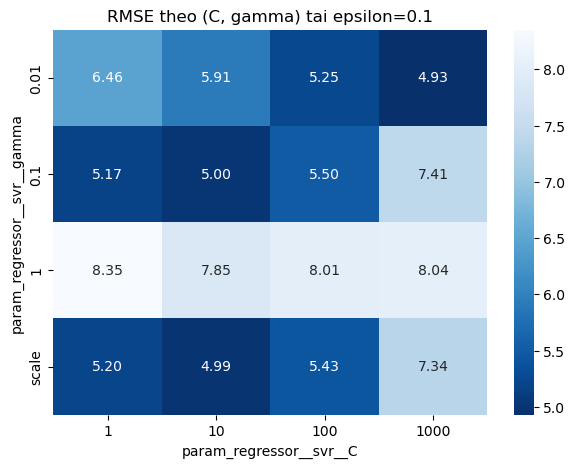

In [13]:
ket_qua_grid = pd.DataFrame(grid.cv_results_)
ket_qua_grid["rmse"] = -ket_qua_grid["mean_test_score"]
# co dinh epsilon o gia tri tot nhat de ve heatmap 2 chieu C x gamma
eps_tot_nhat = grid.best_params_["regressor__svr__epsilon"]
subset = ket_qua_grid[ket_qua_grid["param_regressor__svr__epsilon"] == eps_tot_nhat]
pivot = subset.pivot_table(index="param_regressor__svr__gamma",
                            columns="param_regressor__svr__C", values="rmse")

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues_r")
plt.title(f"RMSE theo (C, gamma) tai epsilon={eps_tot_nhat}")
plt.show()


## 9. Dem support vectors

In [14]:
svr_model = svr_toi_uu.regressor_["svr"]
so_sv = svr_model.n_support_.sum()
print(f"So support vectors: {so_sv} / {len(X_train)} mau train ({so_sv/len(X_train):.1%})")
# So SV thap -> model gon, tong quat hoa tot; SV gan bang toan bo du lieu -> co the dang overfit


So support vectors: 508 / 824 mau train (61.7%)


## 10. Hieu qua cua dac trung mien (water/cement)

In [15]:
feature_cols_goc = ["cement", "slag", "fly_ash", "water", "superplasticizer",
                     "coarse_agg", "fine_agg", "age"]
X_train_goc, X_test_goc = X_train[feature_cols_goc], X_test[feature_cols_goc]

svr_khong_dac_trung = tao_svr(**{k.replace("regressor__svr__", ""): v for k, v in grid.best_params_.items()})
svr_khong_dac_trung.fit(X_train_goc, y_train)
pred_goc = svr_khong_dac_trung.predict(X_test_goc)
rmse_goc = np.sqrt(mean_squared_error(y_test, pred_goc))

print(f"RMSE KHONG co dac trung mien (water_cement_ratio, tong_chat_ket_dinh, log_age): {rmse_goc:.3f}")
print(f"RMSE CO dac trung mien: {rmse_toi_uu:.3f}")
print(f"Cai thien: {(rmse_goc - rmse_toi_uu):.3f} MPa ({(1 - rmse_toi_uu/rmse_goc):.1%})")


RMSE KHONG co dac trung mien (water_cement_ratio, tong_chat_ket_dinh, log_age): 6.041
RMSE CO dac trung mien: 5.351
Cai thien: 0.690 MPa (11.4%)


## 11. So sanh SVR vs XGBoost vs Random Forest

In [16]:
import time
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

mo_hinh_so_sanh = {
    "SVR (toi uu)": svr_toi_uu,
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                             random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}
for ten, m in mo_hinh_so_sanh.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    t_train = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
    print(f"{ten:15s} RMSE={rmse:.3f}  thoi_gian_train={t_train:.3f}s")


SVR (toi uu)    RMSE=5.351  thoi_gian_train=0.827s
XGBoost         RMSE=5.038  thoi_gian_train=0.409s
Random Forest   RMSE=5.233  thoi_gian_train=0.560s


## 12. Thi nghiem kha nang mo rong: nhan du lieu len 10x

SVR train tren du lieu 1x (goc) (824 dong): 0.85s
SVR train tren du lieu 10x (8240 dong): 128.06s


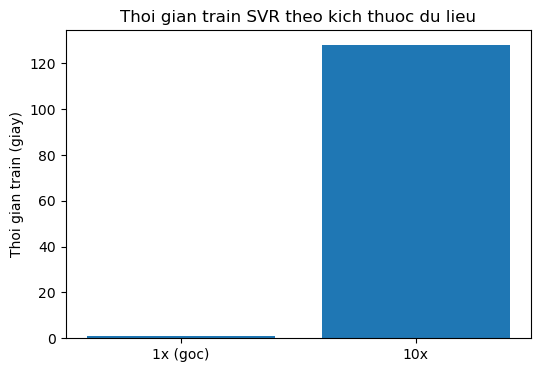

In [17]:
X_train_10x = pd.concat([X_train] * 10, ignore_index=True)
y_train_10x = pd.concat([y_train] * 10, ignore_index=True)

thoi_gian = {}
for ten, n_lan in [("1x (goc)", 1), ("10x", 10)]:
    X_thu, y_thu = (X_train, y_train) if n_lan == 1 else (X_train_10x, y_train_10x)
    t0 = time.time()
    tao_svr(**{k.replace("regressor__svr__", ""): v for k, v in grid.best_params_.items()}).fit(X_thu, y_thu)
    thoi_gian[ten] = time.time() - t0
    print(f"SVR train tren du lieu {ten} ({len(X_thu)} dong): {thoi_gian[ten]:.2f}s")

plt.figure(figsize=(6, 4))
plt.bar(thoi_gian.keys(), thoi_gian.values())
plt.ylabel("Thoi gian train (giay)")
plt.title("Thoi gian train SVR theo kich thuoc du lieu")
plt.show()
# SVR co do phuc tap O(n^2)-O(n^3) -> thoi gian tang nhanh hon tuyen tinh khi du lieu tang
# -> khong phu hop cho du lieu lon (>50.000 dong)


In [18]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# 1. Luu model
joblib.dump(svr_toi_uu, "models/svr_pipeline.joblib")

# 2. Luu 4 hinh theo dung ten README yeu cau
plt.figure(figsize=(6, 4))
plt.bar(["Khong scale", "Co scale"], [rmse_khong_scale, rmse_co_scale])
plt.ylabel("RMSE (MPa)")
plt.title("SVR: khong scale vs co scale")
plt.savefig("reports/scale_vs_noscale.png", dpi=150, bbox_inches="tight"); plt.close()

rmse_kernel = {}
for kernel in ["linear", "rbf", "poly"]:
    m = tao_svr(kernel=kernel, degree=3)
    m.fit(X_train, y_train)
    rmse_kernel[kernel] = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
plt.figure(figsize=(6, 4))
plt.bar(rmse_kernel.keys(), rmse_kernel.values())
plt.ylabel("RMSE (MPa)")
plt.title("So sanh 3 kernel")
plt.savefig("reports/kernel_comparison.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues_r")
plt.title(f"RMSE theo (C, gamma) tai epsilon={eps_tot_nhat}")
plt.savefig("reports/C_gamma_heatmap.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.bar(thoi_gian.keys(), thoi_gian.values())
plt.ylabel("Thoi gian train (giay)")
plt.title("Thoi gian train SVR theo kich thuoc du lieu")
plt.savefig("reports/thoi_gian_train.png", dpi=150, bbox_inches="tight"); plt.close()

# 3. requirements.txt
with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\nseaborn\nxgboost\nxlrd\njoblib\n")

# 4. README.md - huong dan chay + nhan xet ket qua that
readme_content = f"""# TT-20 - SVR: Du doan cuong do chiu nen be tong

## Huong dan chay
1. Cai thu vien: `pip install scikit-learn pandas numpy matplotlib seaborn xgboost xlrd joblib`
2. Dat file `Concrete_Data.xls` cung thu muc voi notebook `notebooks/svr_concrete.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua (model, hinh, requirements) duoc luu vao `models/` va `reports/` khi chay den cell cuoi

## Dac trung tu kien thuc mien
Da tao 3 dac trung: water_cement_ratio (ty le nuoc/xi mang), tong_chat_ket_dinh
(cement + slag + fly_ash), log_age (Age lech phai manh nen dung log1p).
RMSE KHONG co dac trung mien: {rmse_goc:.3f} MPa
RMSE CO dac trung mien: {rmse_toi_uu:.3f} MPa
=> Cai thien {(1 - rmse_toi_uu/rmse_goc):.1%}, xac nhan kien thuc mien giup ich ro ret.

## Nhan xet ket qua

- SVR KHONG scale: RMSE={rmse_khong_scale:.3f}, R2={r2_khong_scale:.3f} — rat kem vi epsilon=0.1
  qua nho so voi thang do y (2-83 MPa), hau het diem nam ngoai ong.
- SVR CO scale ca X va y: RMSE={rmse_co_scale:.3f}, R2={r2_co_scale:.3f} — cai thien ro ret,
  xac nhan SVR bat buoc phai TransformedTargetRegressor de scale nhan.
- Kernel tot nhat: {min(rmse_kernel, key=rmse_kernel.get)} (RMSE={min(rmse_kernel.values()):.3f}).
- Tham so toi uu tu GridSearchCV: {grid.best_params_}
- So support vectors: {so_sv}/{len(X_train)} mau train ({so_sv/len(X_train):.1%}).
- SVR (toi uu) RMSE tren test: {rmse_toi_uu:.3f}, R2={r2_toi_uu:.3f}.
- Thoi gian train tang tu {thoi_gian['1x (goc)']:.2f}s (1x) len {thoi_gian['10x']:.2f}s (10x du lieu)
  — tang nhanh hon tuyen tinh, xac nhan SVR khong phu hop du lieu lon (>50.000 dong).

## Han che
- SVR khong giai thich duoc tung du doan cu the (khong co he so ro rang nhu Linear Regression).
- SVR khong mo rong duoc cho du lieu lon do do phuc tap O(n^2)-O(n^3).
- Model du bao gia tri trung binh, chua uu tien tranh du bao cao hon thuc te — nganh xay dung
  can xem xet du bao phan vi thap (vi du GradientBoostingRegressor loss='quantile', alpha=0.1)
  de an toan ket cau, vi du bao cuong do cao hon thuc te co the gay nguy hiem khi thi cong.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/svr_pipeline.joblib, reports/*.png, requirements.txt, README.md")

Da luu: models/svr_pipeline.joblib, reports/*.png, requirements.txt, README.md
